<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/3DPlatePointCGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

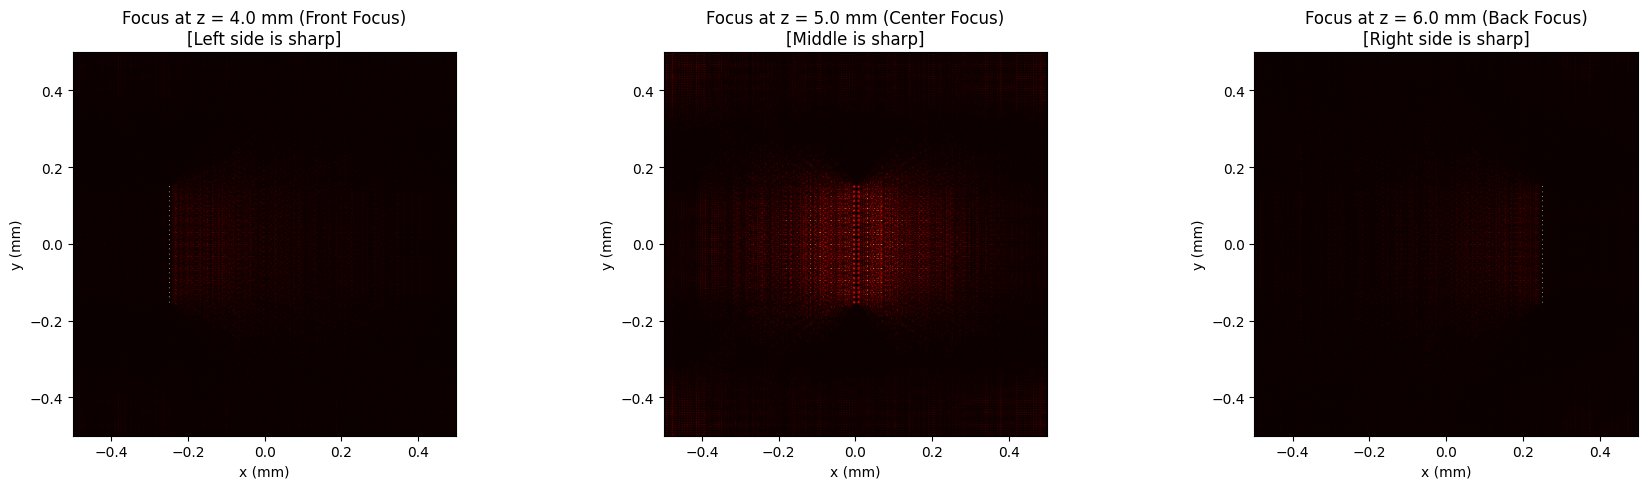

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. パラメータ設定
N = 512                 # グリッドの分割数 (N x N)
L = 1.0e-3              # 計算領域のサイズ [m] (1.0 mm)
wavelength = 632.8e-9   # 光の波長 [m] (632.8 nm)
dx = L / N              # 画素ピッチ [m]

# 座標系の構築
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y)

fx = np.fft.fftfreq(N, d=dx)
fy = np.fft.fftfreq(N, d=dx)
FX, FY = np.meshgrid(fx, fy)

# 2. 角スペクトル法 (ASM) の定義
def propagate_asm(u_in, z_dist, wavelength, FX, FY):
    U_in = np.fft.fft2(u_in)
    term = (1/wavelength)**2 - FX**2 - FY**2
    term[term < 0] = 0
    H = np.exp(1j * 2 * np.pi * z_dist * np.sqrt(term))
    return np.fft.ifft2(U_in * H)

# 3. 【記録フェーズ】3次元で傾いた高密度プレートの生成

# プレートの定義
plate_width = 0.5e-3   # プレートの横幅 (0.5 mm)
plate_height = 0.3e-3  # プレートの縦幅 (0.3 mm)

num_points_x = 40      # 横方向の分割数
num_points_y = 25      # 縦方向の分割数

px_vals = np.linspace(-plate_width/2, plate_width/2, num_points_x)
py_vals = np.linspace(-plate_height/2, plate_height/2, num_points_y)

# 各点の 3次元座標 (x, y, z) を生成
points = []
for px in px_vals:
    for py in py_vals:
        # x 座標に応じて z を 4.0mm から 6.0mm までリニアに変える
        # 左端 (px = -0.25mm) -> z = 4.0mm (手前)
        # 右端 (px = +0.25mm) -> z = 6.0mm (奥)
        pz = 5.0e-3 + (px / (plate_width/2)) * 1.0e-3
        points.append((px, py, pz))

# 各点光源からの光をホログラム面でコヒーレントに重ね合わせ
u_object_at_hologram = np.zeros((N, N), dtype=complex)

for px, py, pz in points:
    ix = np.argmin(np.abs(x - px))
    iy = np.argmin(np.abs(y - py))

    temp_plane = np.zeros((N, N), dtype=complex)
    temp_plane[iy, ix] = 1.0

    # それぞれの点固有の z 距離から伝搬させる
    u_object_at_hologram += propagate_asm(temp_plane, pz, wavelength, FX, FY)

# ゾーンプレート（実部抽出モデル）
I_hologram_real = np.real(u_object_at_hologram)

# 4. 【再生フェーズ】異なる3つの奥行き（4.0mm, 5.0mm, 6.0mm）で再生

u_reference = np.ones((N, N), dtype=complex)
u_reconstruction_plane = I_hologram_real * u_reference

# 手前 z = 4.0 mm にピントを合わせる
u_rec_4mm = propagate_asm(u_reconstruction_plane, -4.0e-3, wavelength, FX, FY)
intensity_4mm = np.abs(u_rec_4mm)**2

# 中央 z = 5.0 mm にピントを合わせる
u_rec_5mm = propagate_asm(u_reconstruction_plane, -5.0e-3, wavelength, FX, FY)
intensity_5mm = np.abs(u_rec_5mm)**2

# 奥 z = 6.0 mm にピントを合わせる
u_rec_6mm = propagate_asm(u_reconstruction_plane, -6.0e-3, wavelength, FX, FY)
intensity_6mm = np.abs(u_rec_6mm)**2

# 5. 結果のプロット

plt.figure(figsize=(18, 5))

# Plot 1: z = 4.0 mm で再生（左側をフォーカス、右側に向けて綺麗にボケる）
plt.subplot(1, 3, 1)
plt.imshow(intensity_4mm / np.max(intensity_4mm), extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='hot')
plt.title("Focus at z = 4.0 mm ")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# Plot 2: z = 5.0 mm で再生（中央をフォーカス、左右に向かって対称にボケる）
plt.subplot(1, 3, 2)
plt.imshow(intensity_5mm / np.max(intensity_5mm), extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='hot')
plt.title("Focus at z = 5.0 mm ")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# Plot 3: z = 6.0 mm で再生（右側をフォーカス、左側に向けて綺麗にボケる）
plt.subplot(1, 3, 3)
plt.imshow(intensity_6mm / np.max(intensity_6mm), extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='hot')
plt.title("Focus at z = 6.0 mm ")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

plt.tight_layout()
plt.show()